In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

EDA

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


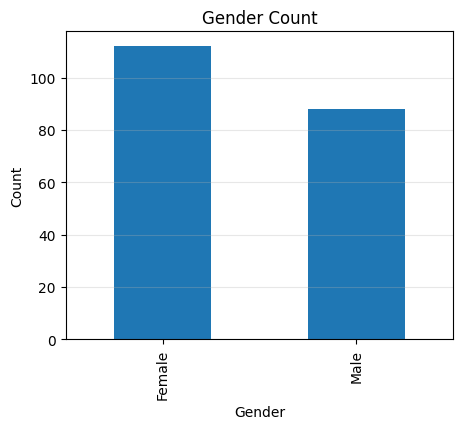

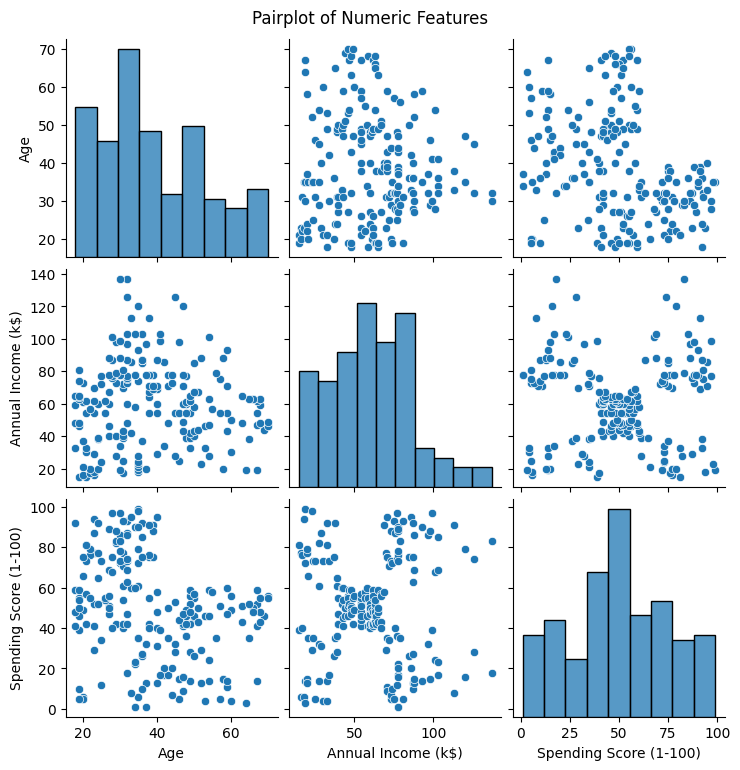

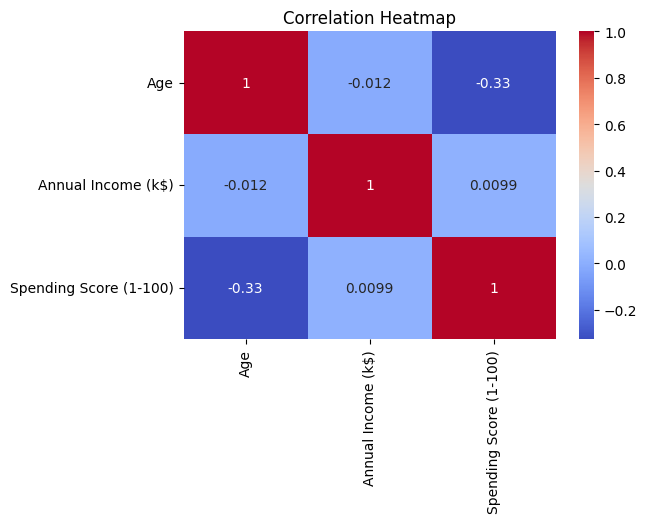

In [10]:
df = pd.read_csv("Mall_Customers.csv")
df.head(10)

display(df.head())
display(df.info())
display(df.describe())
display(df.isnull().sum())


plt.figure(figsize=(5,4))
df["Genre"].value_counts().plot(kind="bar")
plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()


numeric_df = df[["Age",
                 "Annual Income (k$)",
                 "Spending Score (1-100)"]]

sns.pairplot(numeric_df, diag_kind="hist")
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()


corr = numeric_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Preprocessing

In [13]:
le = LabelEncoder()
df["Genre"] = le.fit_transform(df["Genre"])

df_processed = df.drop("CustomerID", axis=1)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_processed)

display(df_processed.head())

Processed DataFrame:


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


Scaled array shape: (200, 4)


K-Means

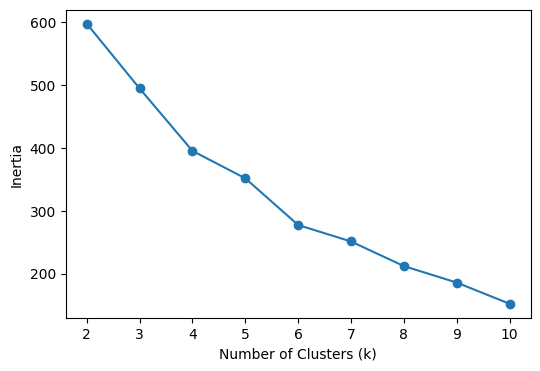

In [15]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)



The inertia drops sharply between K=2 and K=4, then begins to flatten from K=5 onward, indicating diminishing returns. While the exact elbow is not extremely sharp, K=5 is selected as it provides a reasonable balance.

Agglomerative Hierarchical Clustering

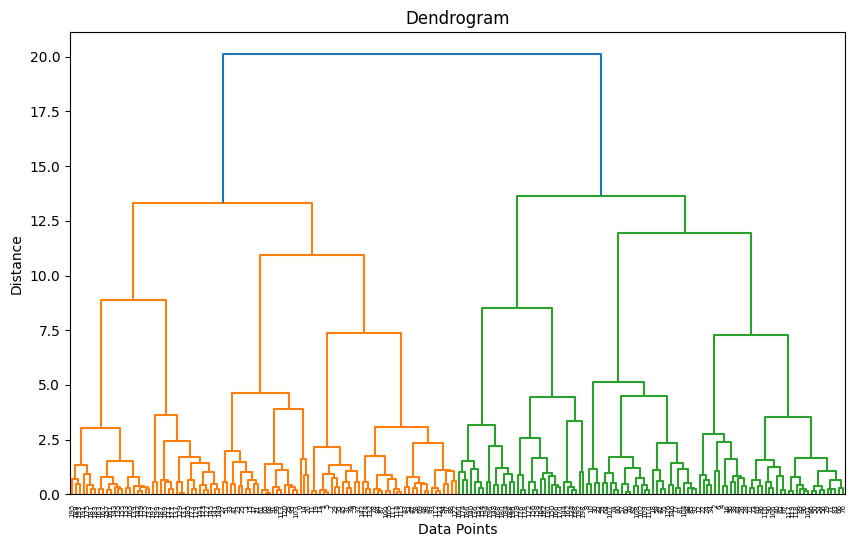

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

plt.figure(figsize=(10, 6))
Z = linkage(scaled_data, method='ward')
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(scaled_data)



The dendrogram shows a large vertical distance around linkage height 20, indicating a major separation into two broad groups. However, a more meaningful cut is slightly lower, around heights 10–12, where 4 to 5 subclusters naturally appear. Based on this structure, 5 clusters were selected for Agglomerative Clustering as it captures a more detailed segmentation while still maintaining clear cluster separation.

DBSCAN

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=4)
dbscan_labels = dbscan.fit_predict(scaled_data)

Evaluation

In [18]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("K-Means Evaluation:")
print("Silhouette Score:", silhouette_score(scaled_data, kmeans_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_data, kmeans_labels))

print("\nAgglomerative Clustering Evaluation:")
print("Silhouette Score:", silhouette_score(scaled_data, agg_labels))
print("Davies-Bouldin Index:", davies_bouldin_score(scaled_data, agg_labels))

print("\nDBSCAN Evaluation:")

dbscan_unique = set(dbscan_labels)

n_clusters_dbscan = len([c for c in dbscan_unique if c != -1])

if n_clusters_dbscan >= 2:
    print("Silhouette Score:", silhouette_score(scaled_data, dbscan_labels))
    print("Davies-Bouldin Index:", davies_bouldin_score(scaled_data, dbscan_labels))
else:
    print("DBSCAN did not produce enough clusters for evaluation.")
    print("Unique labels:", dbscan_unique)



K-Means Evaluation:
Silhouette Score: 0.27191023466188324
Davies-Bouldin Index: 1.181091452406171

Agglomerative Clustering Evaluation:
Silhouette Score: 0.28699413201651747
Davies-Bouldin Index: 1.2197730790225612

DBSCAN Evaluation:
Silhouette Score: 0.12061976322280461
Davies-Bouldin Index: 1.4488023451711347


Agglomerative Clustering achieved the highest silhouette score of 0.287, while K-Means performed similarly with a score of 0.272. DBSCAN produced significantly lower scores, indicating poor cluster separation for this dataset. Davies–Bouldin values also confirm this ranking, with K-Means and Agglomerative both around 1.2, and DBSCAN performing worse at 1.45.